In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

In [65]:
import pandas as pd
import numpy as np

# Load data
# select the correct LLM here
priors_a_given_s = pd.read_csv('../../results/llms/llm_affect_prior_summary_allModels.csv')
priors_a_given_s = priors_a_given_s[priors_a_given_s["model"] == "gemini-1.5-pro"]
print(priors_a_given_s.head())
priors_s = pd.read_csv('../../results/llms/llm_price_prior_summary_allModels.csv')
priors_s = priors_s[priors_s["model"] == "gemini-1.5-pro"]
print(priors_s.head())

speaker_probs = pd.read_csv('../../results/llms/gemini_renormalized_utterance_probs_fixedPrompt_alpha1.csv')
print("Speaker prbs")
print(speaker_probs.head())
# Define goals and items
goals = ["affect-exact", "affect-fuzzy", 
         "state-exact", "state-fuzzy",
          "both-exact", "both-fuzzy"
         ]
items = ["electric kettle", "laptop", "watch"]
states = priors_s['closest_price_space'].unique()
print("Unique states: ", states)
# Initialize posteriors dictionary

    price             item           model  is_price_space  price_rounded  \
1      50  electric kettle  gemini-1.5-pro             1.0           50.0   
4      50           laptop  gemini-1.5-pro             1.0           50.0   
7      50            watch  gemini-1.5-pro             1.0           50.0   
10     51  electric kettle  gemini-1.5-pro             0.0           50.0   
13     51           laptop  gemini-1.5-pro             0.0           50.0   

    closest_price_space  parsed_response  parsed_response_clean  
1                  50.0            0.200                  0.200  
4                  50.0            0.046                  0.046  
7                  50.0            0.200                  0.200  
10                 51.0            0.200                  0.200  
13                 51.0            1.000                  1.000  
    price             item           model  is_price_space  price_rounded  \
1      50  electric kettle  gemini-1.5-pro             1.0      

In [66]:

posteriors = {item: {u: [] for u in speaker_probs['utterance'].unique()} for item in items}

# Posterior calculation
for item in items:
    for u in speaker_probs['utterance'].unique():
        numerator = []
        for s in states:
            for a in [0, 1]:  # A takes values 0 and 1
                # P(S)
                prior_s = priors_s[(priors_s['closest_price_space'] == s) & (priors_s['item'] == item)]['normalized_price_prior'].values[0]
                
                # P(A | S)
                prior_a_given_s = priors_a_given_s[(priors_a_given_s['closest_price_space'] == s) & (priors_a_given_s['item'] == item)]['parsed_response_clean'].values[0]
                prior_a = prior_a_given_s if a == 1 else (1 - prior_a_given_s)
                print("prior_a", prior_a)
                print("prior_s", prior_s)  
                # process the different goals
                total_u_likelihood = 0
                for g in goals:
                    g_split = g.split("-")
                    if g_split[0] != "affect":
                        # P(U | S, A)
                        if g_split[0] == "state":
                            # just an idiosynchracy of accessing the right speaker probs
                            a = 0
                        if g_split[1] == "fuzzy":
                            s_rounded = round(s, -1)
                            likelihood_u = speaker_probs[
                                (speaker_probs['utterance'] == u) &
                                (speaker_probs['state'] == s_rounded) & # 
                                (speaker_probs['item'] == item) &
                                (speaker_probs['affect_valence'] == a) &
                                (speaker_probs['goal'] == g_split[0]) &
                                (speaker_probs['halo'] == "fuzzy")
                            ]['utterance_prob'].values
                        else:
                            likelihood_u = speaker_probs[
                                (speaker_probs['utterance'] == u) &
                                (speaker_probs['state'] == s) &
                                (speaker_probs['item'] == item) &
                                (speaker_probs['affect_valence'] == a) &
                                (speaker_probs['goal'] == g_split[0]) &
                                (speaker_probs['halo'] == "exact")
                            ]['utterance_prob'].values                       
                    else:
                        
                        likelihood_u = speaker_probs[
                            (speaker_probs['utterance'] == u) &
                            (speaker_probs['item'] == item) &
                            (speaker_probs['affect_valence'] == a) &
                            (speaker_probs['goal'] == g_split[0]) 
                        ]['utterance_prob'].values
                        #######
                    print("Goal, likelihoods, ", g, likelihood_u)
                    
                    # sum over the goals
                    assert len(likelihood_u) == 1, "Likelihoods should be unique"
                    
                    total_u_likelihood += (prior_s * prior_a * likelihood_u)
                    
                print("Final likelihood ", likelihood_u)
                assert total_u_likelihood >= 0, f"Negative likelihood: {total_u_likelihood}"
                assert total_u_likelihood < 1, f"likelihood greater than 1: {total_u_likelihood}"
                # Calculate numerator for P(S, A | U)
                numerator.append(total_u_likelihood)
        
        # Normalize the posteriors
        total = sum(numerator)
        if total > 0:
            posteriors[item][u] = [num / total for num in numerator]
        else:
            posteriors[item][u] = [0 for _ in numerator]

# Example: Accessing posteriors
# for item in posteriors.keys():
#     for u, probs in posteriors[item].items():
#         print(f"Item: {item}, Utterance: {u}, Posterior: {probs}")


prior_a 0.8
prior_s 0.4176610978520286
Goal, likelihoods,  affect-exact [0.15081095]
Goal, likelihoods,  affect-fuzzy [0.15081095]
Goal, likelihoods,  state-exact [0.45085306]
Goal, likelihoods,  state-fuzzy [0.45864594]
Goal, likelihoods,  both-exact [0.23196932]
Goal, likelihoods,  both-fuzzy [0.31239519]
Final likelihood  [0.31239519]
prior_a 0.2
prior_s 0.4176610978520286
Goal, likelihoods,  affect-exact [0.16298885]
Goal, likelihoods,  affect-fuzzy [0.16298885]
Goal, likelihoods,  state-exact [0.45085306]
Goal, likelihoods,  state-fuzzy [0.45864594]
Goal, likelihoods,  both-exact [0.23196932]
Goal, likelihoods,  both-fuzzy [0.31239519]
Final likelihood  [0.31239519]
prior_a 0.8
prior_s 0.4325775656324582
Goal, likelihoods,  affect-exact [0.15081095]
Goal, likelihoods,  affect-fuzzy [0.15081095]
Goal, likelihoods,  state-exact [0.22542806]
Goal, likelihoods,  state-fuzzy [0.45864594]
Goal, likelihoods,  both-exact [0.1580395]
Goal, likelihoods,  both-fuzzy [0.31239519]
Final likeli

In [67]:
sum(posteriors['electric kettle'][50])

array([1.])

In [68]:
# Initialize a list to hold rows for the dataframe
posterior_rows = []

# Iterate over items, utterances, and posterior probabilities
for item, utterances in posteriors.items():
    for utterance, probs in utterances.items():
        # Iterate over all (s, a) pairs for the given utterance
        for i, prob in enumerate(probs):
            # Determine the state (s) and affect value (a) from the index
            state_index = i // 2  # Integer division to determine state index
            affect_value = i % 2  # Modulo to determine affect value (0 or 1)
            state = states[state_index]
            
            # Append row to the list
            posterior_rows.append({
                "item": item,
                "utterance": utterance,
                "states": state,
                "a": affect_value,
                "posterior": prob
            })

# Convert the list of rows to a dataframe
posterior_df = pd.DataFrame(posterior_rows)

# Display the dataframe
print(posterior_df)


                item  utterance   states  a                 posterior
0    electric kettle         50     50.0  0      [0.4055919076723105]
1    electric kettle         50     50.0  1     [0.10280478361391746]
2    electric kettle         50     51.0  0     [0.34844348597843117]
3    electric kettle         50     51.0  1      [0.0885679212867276]
4    electric kettle         50    500.0  0  [0.00016150356237646724]
..               ...        ...      ... ..                       ...
595            watch      10001   5001.0  1     [0.06065066918186801]
596            watch      10001  10000.0  0   [0.0031365316408862535]
597            watch      10001  10000.0  1     [0.02736384281110346]
598            watch      10001  10001.0  0    [0.005144624093600424]
599            watch      10001  10001.0  1      [0.0965581985548977]

[600 rows x 5 columns]


In [69]:
# categorize the state utterance pairs

def categorize_s_u_pair(row):
    state = row["states"]
    utterance = row["utterance"]
    # utterance = int(utterance.replace("$", ""))
    if state == utterance:
        interpretation = "exact"
    elif abs(state - utterance) < 5:
        interpretation = "fuzzy"
    elif utterance > state:
        interpretation = "hyperbolic"
    else:
        interpretation = "other"

    return interpretation


In [70]:
posterior_df["category"] = posterior_df.apply(categorize_s_u_pair, axis=1)
posterior_df

,item,utterance,states,a,posterior,category
0,electric kettle,50,50.0,0,[0.4055919076723105],exact
1,electric kettle,50,50.0,1,[0.10280478361391746],exact
2,electric kettle,50,51.0,0,[0.34844348597843117],fuzzy
3,electric kettle,50,51.0,1,[0.0885679212867276],fuzzy
4,electric kettle,50,500.0,0,[0.00016150356237646724],other
...,...,...,...,...,...,...
595,watch,10001,5001.0,1,[0.06065066918186801],hyperbolic
596,watch,10001,10000.0,0,[0.0031365316408862535],fuzzy
597,watch,10001,10000.0,1,[0.02736384281110346],fuzzy
598,watch,10001,10001.0,0,[0.005144624093600424],exact


In [71]:
posterior_df_marginal_states = posterior_df.groupby(
    ['item', 'utterance', 'states']
)['posterior'].sum().reset_index()

posterior_df_marginal_states["category"] = posterior_df_marginal_states.apply(categorize_s_u_pair, axis=1)

# posterior_df_marginal_states.to_csv("../../data/posterior_nesy_gpt-4o-mini_marginal_states.csv", index=False)

### Hyperparameter fitting 

In [72]:
cost = [1.0 + x/10 for x in range(0, 30)]
lambda_ = [1] # [0.0 + x/100 for x in range(0, 100)]

def normalize_model_predictions(model_predictions, lamb):
    normed_model_predictions = {}
    for i in model_predictions["item"].unique():
        item_predictions = model_predictions[model_predictions["item"] == i]
        normed_model_predictions[i] = {}
        for u in item_predictions["utterance"].unique():
            utterance_predictions = item_predictions[item_predictions["utterance"] == u]["posterior"].values
            powered = utterance_predictions**lamb
            print("powered", powered)
            normed_model_predictions[i][u] = powered/sum(powered)
            print("normed", normed_model_predictions[i][u])
    return normed_model_predictions


In [73]:
humans_1b = pd.read_csv("../../human_data/experiment1-normalized.csv")
humans_1b_prices = humans_1b["state"].unique().tolist()
humans_1b_summary = humans_1b.groupby(["state", "utterance", "domain"]).agg({"stateProb": "mean"}).reset_index()
print("Len of human data ", len(humans_1b_summary), humans_1b_summary.head())
humans_1b_summary = humans_1b_summary.rename(columns={"domain": "item", "state": "states"})
humans_1b_summary

Len of human data  300    state  utterance           domain  stateProb
0     50         50  electric kettle   0.418484
1     50         50           laptop   0.214707
2     50         50            watch   0.409710
3     50         51  electric kettle   0.364112
4     50         51           laptop   0.123671


,states,utterance,item,stateProb
0,50,50,electric kettle,0.418484
1,50,50,laptop,0.214707
2,50,50,watch,0.409710
3,50,51,electric kettle,0.364112
4,50,51,laptop,0.123671
...,...,...,...,...
295,10001,10000,laptop,0.109323
296,10001,10000,watch,0.166887
297,10001,10001,electric kettle,0.186796
298,10001,10001,laptop,0.230164


In [74]:
mses = {}
# for c in cost:
for l in lambda_: 
    print("Lambda: ", l)
    # Apply softmax to the `posteriors` dictionary
    # nesy_cost_model_predictions = get_model_predictions(posteriors, c)
    nesy_cost_lambda_normed = normalize_model_predictions(posterior_df_marginal_states, l)
    mse = 0
    for obj in ["electric kettle", "watch", "laptop"]:
        nesy_cost_lambda_normed_obj = nesy_cost_lambda_normed[obj] #[nesy_cost_lambda_normed["item"] == obj]
        for u in nesy_cost_lambda_normed_obj: # ["utterance"].unique():
            print("u ", u)
            human_data = humans_1b_summary[humans_1b_summary["item"] == obj]
            human_data = human_data[human_data["utterance"] == u ]["stateProb"].values
            print("human data ", human_data)
            nesy_cost_lambda_normed_obj_u = nesy_cost_lambda_normed_obj[u] #["utterance"] == u]
            print("nesy data ", nesy_cost_lambda_normed_obj_u)
            mse += sum((human_data - nesy_cost_lambda_normed_obj_u)**2)
    mses[l] = mse

Lambda:  1
powered [array([0.50839669]) array([0.43701141]) array([0.00224633])
 array([0.03892498]) array([0.00227119]) array([0.00224316])
 array([0.00225114]) array([0.00221214]) array([0.00222148])
 array([0.00222148])]
normed [array([0.50839669]) array([0.43701141]) array([0.00224633])
 array([0.03892498]) array([0.00227119]) array([0.00224316])
 array([0.00225114]) array([0.00221214]) array([0.00222148])
 array([0.00222148])]
powered [array([0.38541535]) array([0.57808975]) array([0.00155725])
 array([0.0257419]) array([0.00158431]) array([0.00154608])
 array([0.00154986]) array([0.00149668]) array([0.00150942])
 array([0.00150942])]
normed [array([0.38541535]) array([0.57808975]) array([0.00155725])
 array([0.0257419]) array([0.00158431]) array([0.00154608])
 array([0.00154986]) array([0.00149668]) array([0.00150942])
 array([0.00150942])]
powered [array([0.3244116]) array([0.32560167]) array([0.01854759])
 array([0.30401133]) array([0.0046487]) array([0.00459326])
 array([0.004

In [75]:
mses_df = pd.DataFrame(mses.items(), columns=["lambda", "mse"])
mses_df

,lambda,mse
0,1,[2.030323568815758]


<Axes: >

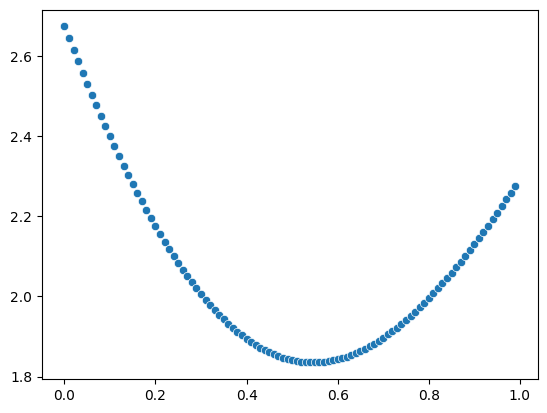

In [36]:
# plot a density plot of the MSEs over the lambda values

import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x = mses.keys() , y = mses.values())

In [76]:
min_mse = min(mses.values())
best_lambdas = []
for key in mses.keys():
    if mses[key] == min_mse:
        best_lambdas.append(key)

print(best_lambdas)

[1]


In [77]:
best_nesy_predictions = normalize_model_predictions(posterior_df_marginal_states, 1) # 0.55

powered [array([0.50839669]) array([0.43701141]) array([0.00224633])
 array([0.03892498]) array([0.00227119]) array([0.00224316])
 array([0.00225114]) array([0.00221214]) array([0.00222148])
 array([0.00222148])]
normed [array([0.50839669]) array([0.43701141]) array([0.00224633])
 array([0.03892498]) array([0.00227119]) array([0.00224316])
 array([0.00225114]) array([0.00221214]) array([0.00222148])
 array([0.00222148])]
powered [array([0.38541535]) array([0.57808975]) array([0.00155725])
 array([0.0257419]) array([0.00158431]) array([0.00154608])
 array([0.00154986]) array([0.00149668]) array([0.00150942])
 array([0.00150942])]
normed [array([0.38541535]) array([0.57808975]) array([0.00155725])
 array([0.0257419]) array([0.00158431]) array([0.00154608])
 array([0.00154986]) array([0.00149668]) array([0.00150942])
 array([0.00150942])]
powered [array([0.3244116]) array([0.32560167]) array([0.01854759])
 array([0.30401133]) array([0.0046487]) array([0.00459326])
 array([0.00459744]) arr

In [78]:
posterior_rows = []
for item, utterances in best_nesy_predictions.items():
    for utterance, probs in utterances.items():
        # Iterate over all (s, a) pairs for the given utterance
        for i, prob in enumerate(probs):
            # Determine the state (s) and affect value (a) from the index
            state = states[i]
            
            # Append row to the list
            posterior_rows.append({
                "item": item,
                "utterance": utterance,
                "states": state,
                "posterior": prob
            })

# Convert the list of rows to a dataframe
best_nesy_predictions_df = pd.DataFrame(posterior_rows)

# Display the dataframe
print(best_nesy_predictions_df)


                item  utterance   states                posterior
0    electric kettle         50     50.0     [0.5083966912862278]
1    electric kettle         50     51.0     [0.4370114072651586]
2    electric kettle         50    500.0  [0.0022463305598042177]
3    electric kettle         50    501.0    [0.03892498471226466]
4    electric kettle         50   1000.0    [0.00227119059482616]
..               ...        ...      ...                      ...
295            watch      10001   1001.0    [0.06868625774637999]
296            watch      10001   5000.0    [0.06411895165574234]
297            watch      10001   5001.0    [0.06469672424021217]
298            watch      10001  10000.0    [0.03050037445198972]
299            watch      10001  10001.0    [0.10170282264849814]

[300 rows x 4 columns]


In [79]:
best_nesy_predictions_df["category"] = best_nesy_predictions_df.apply(categorize_s_u_pair, axis=1)

In [80]:
# best_nesy_predictions_df.to_csv("../../data/posterior_nesy-gemini_fixedPrompt_alpha1.csv", index=False)